In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset
device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

In [7]:
#Import files
data_dir = Path("data")
episodes = []
for fp in sorted(data_dir.glob("data*.npz")):
    z = np.load(fp)
    episodes.append(z["data"]) 
len(episodes), episodes[1].shape

(27, (102, 13))

In [8]:
#Look at file data.
episode_data = episodes[2]
episode_data[100:150, 12:14]

array([[0.02885356],
       [0.03377135]])

In [12]:
#Structure input files for LSTM
from copy import deepcopy
lookback = 5

def parse_data(data, lookback): #TODO: Add padding so that first few values can be added to train
    data = deepcopy(data)
    X= []
    Y = []    #NN outputs force and torque, each Y_i should be accompanied with states from X_i-5 to X_i
    # print (data[1].shape)
    for i in range(len(data)): #go across all episodes  
        episode_data = data[i]
        episode_length = episode_data.shape[0]
        Y_new = episode_data[lookback:, 11:13] #Get all force and torque vectors. Ignore first 5 elements since no history
        print("Y_new Shape", Y_new.shape)
        Y.append(Y_new)

        #Need shape (ep_length, lookback, data)
        episode_data_x = episode_data[:, 1:12] #shape 2000, 11
        for j in range(episode_length - lookback):   #TODO def not the most efficient way to parse all the data
            row_xs = []
            for k in range(lookback):
                hist_timestamp = j + k
                x_hist = episode_data_x[hist_timestamp,:]
                row_xs.append(x_hist)
                #add X hist
            X.append(row_xs)

    #Combine data cross all episodes into one
    X= np.array(X)
    print(Y[0].shape)
    Y = np.concatenate(Y, axis=0)
    return X, Y

X, Y = parse_data(episodes, lookback)
print("X Shape",X.shape)
print("Y Shape", Y.shape)
# Y[1000:1100, :]

Y_new Shape (297, 2)
Y_new Shape (97, 2)
Y_new Shape (97, 2)
Y_new Shape (97, 2)
Y_new Shape (197, 2)
Y_new Shape (297, 2)
Y_new Shape (297, 2)
Y_new Shape (197, 2)
Y_new Shape (197, 2)
Y_new Shape (297, 2)
Y_new Shape (297, 2)
Y_new Shape (297, 2)
Y_new Shape (97, 2)
Y_new Shape (297, 2)
Y_new Shape (97, 2)
Y_new Shape (97, 2)
Y_new Shape (97, 2)
Y_new Shape (97, 2)
Y_new Shape (147, 2)
Y_new Shape (147, 2)
Y_new Shape (297, 2)
Y_new Shape (297, 2)
Y_new Shape (297, 2)
Y_new Shape (297, 2)
Y_new Shape (297, 2)
Y_new Shape (297, 2)
Y_new Shape (447, 2)
(297, 2)
X Shape (5969, 5, 11)
Y Shape (5969, 2)


In [13]:
#Post process data
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler(feature_range=(-1, 1))
# X = scaler.fit_transform(X)
# Y = scaler.fit_transform(Y)

split_index = int(len(X) * 0.95)
X_train = X[:split_index]
X_test = X[split_index:]

Y_train = Y[:split_index]
Y_test = Y[split_index:]

X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()


X_train.shape, X_test.shape, Y_train.shape, Y_test.shape


(torch.Size([5670, 5, 11]),
 torch.Size([299, 5, 11]),
 torch.Size([5670, 2]),
 torch.Size([299, 2]))

In [14]:
class TrajectoryDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.Y[i]

train_dataset = TrajectoryDataset(X_train, Y_train)
test_dataset = TrajectoryDataset(X_test, Y_test)

from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [15]:
for _, batch in enumerate(train_loader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)
    break

torch.Size([16, 5, 11]) torch.Size([16, 2])


In [16]:
class LSTM(nn.Module):

    # input size = number features = 11
    #hidden size can be anything, use 20 for now
    #num_stacked_layers, idk what it does
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layers,
                            batch_first=True)

        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTM(11, 20, 1)

model.to(device)
model

LSTM(
  (lstm): LSTM(11, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=2, bias=True)
)

In [17]:
loss_function = nn.MSELoss()
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
num_epochs = 10

def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        output = model(x_batch)
        # print("output", output)
        # print(output.shape, y_batch.shape)
        # print(
        #     output[1, :].detach().cpu().numpy(),
        #     y_batch[1, :].detach().cpu().numpy()
        # )        
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_index % 100 == 99:  # print every 100 batches
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index+1,
                                                    avg_loss_across_batches))
            running_loss = 0.0
    print()

def validate_one_epoch():
    model.train(False)
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(test_loader)

    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()

In [18]:


for epoch in range(num_epochs):
    train_one_epoch()
    validate_one_epoch()

Epoch: 1
Batch 100, Loss: 2.828
Batch 200, Loss: 2.676
Batch 300, Loss: 1.908

Val Loss: 1.054
***************************************************

Epoch: 2
Batch 100, Loss: 1.404
Batch 200, Loss: 2.603
Batch 300, Loss: 1.697

Val Loss: 1.137
***************************************************

Epoch: 3
Batch 100, Loss: 1.926
Batch 200, Loss: 0.813
Batch 300, Loss: 2.563

Val Loss: 0.889
***************************************************

Epoch: 4
Batch 100, Loss: 0.863
Batch 200, Loss: 2.666
Batch 300, Loss: 1.130

Val Loss: 0.794
***************************************************

Epoch: 5
Batch 100, Loss: 1.513
Batch 200, Loss: 0.411
Batch 300, Loss: 2.315

Val Loss: 0.787
***************************************************

Epoch: 6
Batch 100, Loss: 1.995
Batch 200, Loss: 1.606
Batch 300, Loss: 0.545

Val Loss: 0.836
***************************************************

Epoch: 7
Batch 100, Loss: 0.927
Batch 200, Loss: 0.739
Batch 300, Loss: 2.566

Val Loss: 0.854
*****************

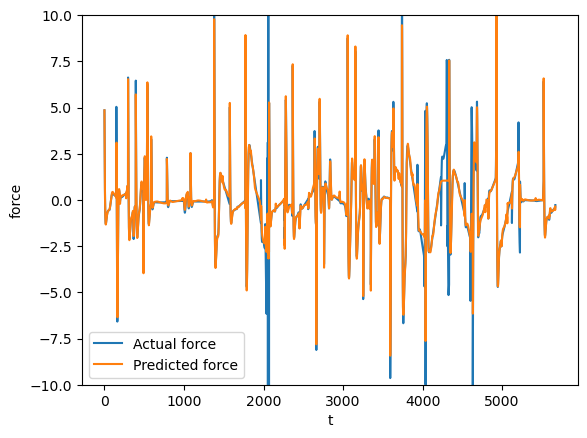

In [23]:
with torch.no_grad():
    predicted = model(X_train.to(device)).to('cpu').numpy()


plt.plot(Y_train[:,0], label='Actual force')
plt.plot(predicted[:,0], label='Predicted force')
plt.xlabel('t')
plt.ylim(-10, 10)
plt.ylabel('force')
plt.legend()
plt.show()


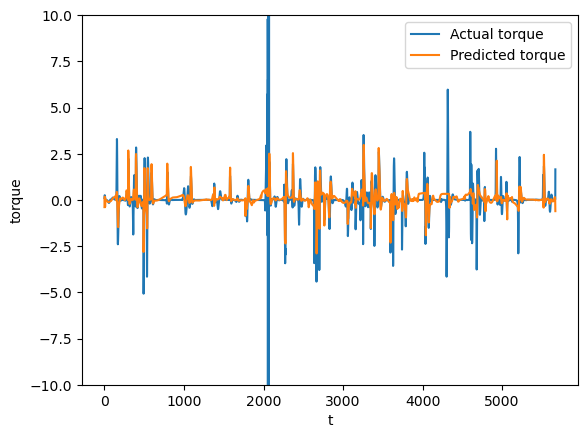

In [22]:
with torch.no_grad():
    predicted = model(X_train.to(device)).to('cpu').numpy()


plt.plot(Y_train[:,1], label='Actual torque')
plt.plot(predicted[:,1], label='Predicted torque')
plt.xlabel('t')
plt.ylabel('torque')
plt.ylim(-10, 10)
plt.legend()
plt.show()